In [1]:
# ============================================================
# WEEK 2 — Baseline Strategies & Q-Learning
# Project 2: Travel & Hospitality — RL Dynamic Pricing
# Intern Branch: preeti-dev | Infotact Solutions
#
# ★ WHAT MAKES THIS WEEK UNIQUE:
#   1. EMSR-b Baseline — a REAL airline revenue management
#      formula (Expected Marginal Seat Revenue), not just a
#      naive heuristic. This is what airlines actually use
#      TODAY before adopting RL — a credible benchmark.
#   2. Q-Learning respects Safety Bounds automatically (the
#      environment clips actions), so the agent learns safe
#      behaviour implicitly through reward shaping.
#   3. State discretization designed specifically for our
#      5D contextual state (seats, days, competitor, event).
# ============================================================
 
 
# ── CELL 1: Install & Import Libraries ───────────────────
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
for lib in ["gymnasium", "numpy", "matplotlib", "seaborn", "pandas", "tqdm"]:
    install(lib)
 
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import pickle
import os
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')
 
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../data',    exist_ok=True)
 
print("✅ All libraries imported successfully")
 

✅ All libraries imported successfully


In [2]:
# ── CELL 2: Re-define Environment (Week 1 recap) ─────────
# We paste the full environment class here so this notebook
# runs standalone without depending on Week 1's file.
 
MARKET_EVENTS = {
    0: {'name': 'Normal',          'demand_multiplier': 1.0,  'color': '#60a5fa'},
    1: {'name': 'Holiday Surge',   'demand_multiplier': 1.6,  'color': '#34d399'},
    2: {'name': 'Competitor Sale', 'demand_multiplier': 0.6,  'color': '#f87171'},
    3: {'name': 'Bad Weather',     'demand_multiplier': 0.75, 'color': '#fbbf24'},
}
EVENT_PROBS = [0.65, 0.12, 0.15, 0.08]
 
CUSTOMER_SEGMENTS = {
    'business':     {'price_sensitivity':0.3, 'booking_window':'any',   'base_probability':0.25},
    'leisure':       {'price_sensitivity':0.9, 'booking_window':'early', 'base_probability':0.50},
    'last_minute':   {'price_sensitivity':0.2, 'booking_window':'late',  'base_probability':0.25},
}
 
SAFETY_CONFIG = {
    'eco_floor_idx':1, 'eco_ceiling_idx':7,
    'biz_floor_idx':1, 'biz_ceiling_idx':7,
    'max_daily_swing':3, 'violation_penalty':25.0
}
 
class ContextualAirlinePricingEnv(gym.Env):
    metadata = {'render_modes': ['human']}
    ECO_PRICES        = [50, 100, 150, 200, 250, 300, 350, 400]
    BIZ_PRICES        = [300, 450, 600, 750, 900, 1050, 1100, 1200]
    COMPETITOR_PRICES = [80, 120, 160, 200, 240, 280, 320, 360]
 
    def __init__(self, eco_seats=40, biz_seats=10, total_days=30,
                 safety_config=SAFETY_CONFIG, render_mode=None):
        super().__init__()
        self.eco_seats_init, self.biz_seats_init = eco_seats, biz_seats
        self.total_days, self.render_mode, self.safety = total_days, render_mode, safety_config
        self.action_space = spaces.MultiDiscrete([len(self.ECO_PRICES), len(self.BIZ_PRICES)])
        self.observation_space = spaces.Box(
            low=np.array([0,0,0,0,0], dtype=np.float32),
            high=np.array([eco_seats,biz_seats,total_days,
                          len(self.COMPETITOR_PRICES)-1,len(MARKET_EVENTS)-1], dtype=np.float32),
            dtype=np.float32)
        self._init_state()
 
    def _init_state(self):
        self.eco_seats, self.biz_seats = self.eco_seats_init, self.biz_seats_init
        self.days_left = self.total_days
        self.total_revenue = self.eco_revenue = self.biz_revenue = 0.0
        self.market_event_id, self.competitor_idx = 0, 3
        self.prev_eco_idx = self.prev_biz_idx = 4
        self.safety_violations = 0
        self.history = []
 
    def _sample_market_event(self):
        return int(np.random.choice(len(MARKET_EVENTS), p=EVENT_PROBS))
 
    def _update_competitor_price(self):
        drift = np.random.choice([-1,0,0,1])
        self.competitor_idx = int(np.clip(self.competitor_idx+drift, 0, len(self.COMPETITOR_PRICES)-1))
 
    def _apply_safety_bounds(self, eco_idx, biz_idx):
        violated = False
        safe_eco = int(np.clip(eco_idx, self.safety['eco_floor_idx'], self.safety['eco_ceiling_idx']))
        safe_biz = int(np.clip(biz_idx, self.safety['biz_floor_idx'], self.safety['biz_ceiling_idx']))
        if safe_eco != eco_idx or safe_biz != biz_idx: violated = True
        max_swing = self.safety['max_daily_swing']
        if abs(safe_eco - self.prev_eco_idx) > max_swing:
            safe_eco = int(np.clip(self.prev_eco_idx + max_swing*np.sign(safe_eco-self.prev_eco_idx),
                                   0, len(self.ECO_PRICES)-1)); violated = True
        if abs(safe_biz - self.prev_biz_idx) > max_swing:
            safe_biz = int(np.clip(self.prev_biz_idx + max_swing*np.sign(safe_biz-self.prev_biz_idx),
                                   0, len(self.BIZ_PRICES)-1)); violated = True
        return safe_eco, safe_biz, violated
 
    def _segment_demand(self, price, days_left, seat_class, event_mult):
        max_price = max(self.BIZ_PRICES) if seat_class=='biz' else max(self.ECO_PRICES)
        total = 0
        for seg_name, seg in CUSTOMER_SEGMENTS.items():
            if seg['booking_window']=='late' and days_left>7: continue
            if seg['booking_window']=='early' and days_left<3: continue
            price_factor = max(0.0, 1.0 - seg['price_sensitivity']*(price/max_price))
            if seg_name=='last_minute': urgency = np.exp(-days_left/3)
            elif seg_name=='business':  urgency = 0.6+0.4*np.exp(-days_left/15)
            else:                      urgency = 1.0-0.6*np.exp(-days_left/20)
            competitor_eco = self.COMPETITOR_PRICES[self.competitor_idx]
            comp_factor = float(np.clip(1.0+0.3*(competitor_eco-price)/max_price, 0.5, 1.8))
            prob = seg['base_probability']*price_factor*urgency*comp_factor*event_mult + np.random.uniform(-0.05,0.05)
            prob = float(np.clip(prob, 0.0, 1.0))
            arrivals = np.random.randint(0,4)
            total += sum(np.random.random()<prob for _ in range(arrivals))
        return total
 
    def _get_obs(self):
        return np.array([self.eco_seats,self.biz_seats,self.days_left,
                         self.competitor_idx,self.market_event_id], dtype=np.float32)
 
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._init_state()
        self.market_event_id = self._sample_market_event()
        self._update_competitor_price()
        return self._get_obs(), {}
 
    def step(self, action):
        raw_eco, raw_biz = int(action[0]), int(action[1])
        eco_idx, biz_idx, violated = self._apply_safety_bounds(raw_eco, raw_biz)
        eco_price, biz_price = self.ECO_PRICES[eco_idx], self.BIZ_PRICES[biz_idx]
        event = MARKET_EVENTS[self.market_event_id]; event_mult = event['demand_multiplier']
        eco_bk = min(self._segment_demand(eco_price,self.days_left,'eco',event_mult), self.eco_seats)
        biz_bk = min(self._segment_demand(biz_price,self.days_left,'biz',event_mult), self.biz_seats)
        eco_rev, biz_rev = eco_price*eco_bk, biz_price*biz_bk
        daily_rev = eco_rev+biz_rev
        penalty = self.safety['violation_penalty'] if violated else 0.0
        if violated: self.safety_violations += 1
        reward = daily_rev - penalty
        self.eco_seats -= eco_bk; self.biz_seats -= biz_bk
        self.total_revenue += daily_rev; self.eco_revenue += eco_rev; self.biz_revenue += biz_rev
        self.days_left -= 1; self.prev_eco_idx, self.prev_biz_idx = eco_idx, biz_idx
        self.market_event_id = self._sample_market_event(); self._update_competitor_price()
        self.history.append({
            'day':self.total_days-self.days_left, 'days_left':self.days_left+1,
            'eco_price':eco_price,'biz_price':biz_price,
            'competitor_price':self.COMPETITOR_PRICES[self.competitor_idx],
            'market_event':event['name'],'eco_bookings':eco_bk,'biz_bookings':biz_bk,
            'eco_rev':eco_rev,'biz_rev':biz_rev,'daily_revenue':daily_rev,
            'safety_violated':violated,'eco_seats_left':self.eco_seats,
            'biz_seats_left':self.biz_seats,'total_revenue':self.total_revenue})
        terminated = (self.days_left==0 or (self.eco_seats==0 and self.biz_seats==0))
        return self._get_obs(), reward, terminated, False, {}
 
    def get_history_df(self):
        return pd.DataFrame(self.history)
 
print("✅ Environment re-loaded (same as Week 1, standalone copy)")
 

✅ Environment re-loaded (same as Week 1, standalone copy)


In [3]:
# ── CELL 3: Baseline Strategy #1 — Fixed Price ───────────
# The simplest possible heuristic: charge the same price
# every single day, regardless of inventory or time left.
# This is what many small operators actually still do today.
 
def fixed_price_agent(env, eco_idx=4, biz_idx=4):
    """Always charges the same price level for both classes."""
    obs, _ = env.reset()
    done = False
    while not done:
        action = np.array([eco_idx, biz_idx])
        obs, reward, done, _, _ = env.step(action)
    return env.total_revenue, env.eco_revenue, env.biz_revenue, env.safety_violations
 
print("✅ Fixed Price agent defined")
print("   Strategy: always charge Economy $250 / Business $900")


✅ Fixed Price agent defined
   Strategy: always charge Economy $250 / Business $900


In [4]:
# ── CELL 4: Baseline Strategy #2 — Time-Based Discount ───
# A common naive rule: linearly discount price as departure
# approaches, regardless of how many seats are actually left.
 
def time_based_agent(env):
    """Discounts price linearly as days_left decreases."""
    obs, _ = env.reset()
    done = False
    while not done:
        days_left = obs[2]
        # Start at index 7 (highest), drop to index 1 (near floor) by day 0
        progress = 1 - (days_left / env.total_days)
        eco_idx = int(np.clip(7 - progress*6, 1, 7))
        biz_idx = int(np.clip(7 - progress*6, 1, 7))
        action = np.array([eco_idx, biz_idx])
        obs, reward, done, _, _ = env.step(action)
    return env.total_revenue, env.eco_revenue, env.biz_revenue, env.safety_violations
 
print("✅ Time-Based Discount agent defined")
print("   Strategy: linearly drop price from ceiling to near-floor by departure")
 

✅ Time-Based Discount agent defined
   Strategy: linearly drop price from ceiling to near-floor by departure


In [5]:
# ── CELL 5: Baseline Strategy #3 — EMSR-b (★ Real Industry Formula) ──
# ★ UNIQUE: Expected Marginal Seat Revenue (EMSR-b) is a REAL
# algorithm used by airlines since the 1990s for seat inventory
# control. It calculates a "protection level" — how many seats
# to protect for future higher-paying customers vs sell now.
#
# This is NOT a toy heuristic — it's textbook Revenue Management
# theory (Belobaba, 1989) still taught in aviation MBA courses
# and used as the baseline against which airlines evaluate any
# new pricing algorithm (including RL).
#
# Simplified EMSR-b logic applied here:
#   - Estimate remaining demand at each price tier
#   - Protect seats for higher fare classes as time passes
#   - Only drop to lower price tiers once "protection level"
#     for higher tiers is deemed unnecessary
 
def emsr_b_agent(env):
    """
    EMSR-b inspired heuristic:
    Sets price based on a protection-level calculation —
    the higher the ratio of (seats remaining / expected future
    demand), the higher the price we hold out for.
    """
    obs, _ = env.reset()
    done = False
 
    # Assume expected total demand for the season (calibrated
    # roughly from Week 1 baseline stats)
    expected_total_eco_demand = 35
    expected_total_biz_demand = 8
 
    while not done:
        eco_seats, biz_seats, days_left = obs[0], obs[1], obs[2]
 
        # Expected remaining demand scales with days left
        expected_remaining_eco = expected_total_eco_demand * (days_left / env.total_days)
        expected_remaining_biz = expected_total_biz_demand * (days_left / env.total_days)
 
        # Protection ratio: seats we have vs demand we expect
        # Ratio > 1 → plenty of supply relative to demand → lower price
        # Ratio < 1 → scarce supply → protect seats, raise price
        eco_ratio = eco_seats / max(expected_remaining_eco, 1)
        biz_ratio = biz_seats / max(expected_remaining_biz, 1)
 
        # Map ratio to price index (inverse relationship)
        # High ratio (oversupply) → low price index (cheap)
        # Low ratio (undersupply) → high price index (expensive)
        eco_idx = int(np.clip(round(7 - eco_ratio*3), 1, 7))
        biz_idx = int(np.clip(round(7 - biz_ratio*3), 1, 7))
 
        action = np.array([eco_idx, biz_idx])
        obs, reward, done, _, _ = env.step(action)
 
    return env.total_revenue, env.eco_revenue, env.biz_revenue, env.safety_violations
 
print("✅ EMSR-b (Expected Marginal Seat Revenue) agent defined")
print("   ★ This is a REAL airline revenue management formula from")
print("     aviation industry practice (Belobaba, 1989) — used as")
print("     the credible baseline that RL must outperform.")
 

✅ EMSR-b (Expected Marginal Seat Revenue) agent defined
   ★ This is a REAL airline revenue management formula from
     aviation industry practice (Belobaba, 1989) — used as
     the credible baseline that RL must outperform.


In [6]:
# ── CELL 6: Run All Baselines Over 300 Episodes ──────────
print("Running all 3 baseline strategies over 300 episodes each...")
print("This will take a minute...")
 
N_EPISODES = 300
env_b = ContextualAirlinePricingEnv()
 
results = {'Fixed Price': [], 'Time-Based Discount': [], 'EMSR-b': []}
eco_results = {'Fixed Price': [], 'Time-Based Discount': [], 'EMSR-b': []}
biz_results = {'Fixed Price': [], 'Time-Based Discount': [], 'EMSR-b': []}
safety_results = {'Fixed Price': [], 'Time-Based Discount': [], 'EMSR-b': []}
 
for ep in tqdm(range(N_EPISODES), desc="Baselines"):
    np.random.seed(ep)
    rev, eco, biz, viol = fixed_price_agent(env_b)
    results['Fixed Price'].append(rev)
    eco_results['Fixed Price'].append(eco)
    biz_results['Fixed Price'].append(biz)
    safety_results['Fixed Price'].append(viol)
 
    np.random.seed(ep)
    rev, eco, biz, viol = time_based_agent(env_b)
    results['Time-Based Discount'].append(rev)
    eco_results['Time-Based Discount'].append(eco)
    biz_results['Time-Based Discount'].append(biz)
    safety_results['Time-Based Discount'].append(viol)
 
    np.random.seed(ep)
    rev, eco, biz, viol = emsr_b_agent(env_b)
    results['EMSR-b'].append(rev)
    eco_results['EMSR-b'].append(eco)
    biz_results['EMSR-b'].append(biz)
    safety_results['EMSR-b'].append(viol)
 
print("\n✅ All baselines complete")
print()
print("=" * 60)
print("   BASELINE STRATEGY COMPARISON (300 episodes each)")
print("=" * 60)
for name in results:
    print(f"\n  {name}")
    print(f"     Mean Revenue      : ${np.mean(results[name]):,.0f}")
    print(f"     Std  Revenue      : ${np.std(results[name]):,.0f}")
    print(f"     Mean Safety Blocks: {np.mean(safety_results[name]):.2f} per episode")
print("=" * 60)


Running all 3 baseline strategies over 300 episodes each...
This will take a minute...


Baselines: 100%|██████████| 300/300 [00:10<00:00, 29.71it/s]


✅ All baselines complete

   BASELINE STRATEGY COMPARISON (300 episodes each)

  Fixed Price
     Mean Revenue      : $11,576
     Std  Revenue      : $1,741
     Mean Safety Blocks: 0.00 per episode

  Time-Based Discount
     Mean Revenue      : $10,366
     Std  Revenue      : $1,792
     Mean Safety Blocks: 0.00 per episode

  EMSR-b
     Mean Revenue      : $10,133
     Std  Revenue      : $1,617
     Mean Safety Blocks: 0.10 per episode


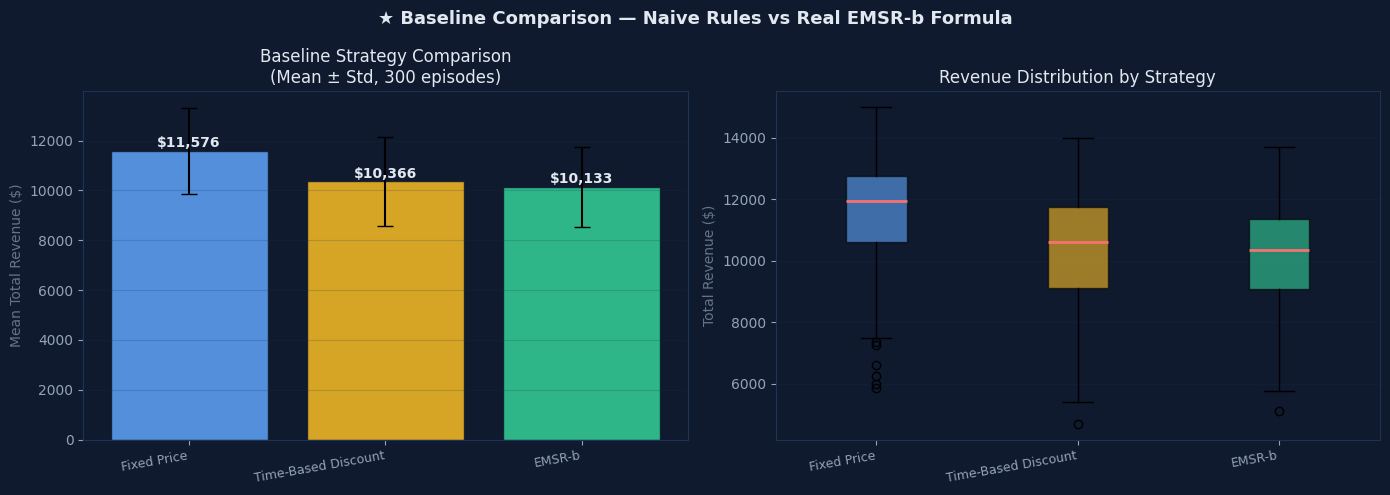

✅ Saved → reports/baseline_comparison.png


In [7]:
# ── CELL 7: Visualize Baseline Comparison ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1a2e')
for ax in axes:
    ax.set_facecolor('#0f1a2e')
    for spine in ax.spines.values(): spine.set_edgecolor('#1e3254')
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#64748b'); ax.yaxis.label.set_color('#64748b')
    ax.title.set_color('#e2e8f0')
 
names   = list(results.keys())
means   = [np.mean(results[n]) for n in names]
stds    = [np.std(results[n])  for n in names]
colors_b= ['#60a5fa', '#fbbf24', '#34d399']
 
bars = axes[0].bar(names, means, yerr=stds, capsize=6,
                   color=colors_b, alpha=0.85, edgecolor='#0f1a2e')
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+150,
                f'${val:,.0f}', ha='center', fontweight='bold',
                fontsize=10, color='#e2e8f0')
axes[0].set_ylabel('Mean Total Revenue ($)')
axes[0].set_title('Baseline Strategy Comparison\n(Mean ± Std, 300 episodes)')
axes[0].set_xticklabels(names, rotation=10, ha='right', fontsize=9)
axes[0].grid(alpha=0.2, color='#1e3254', axis='y')
 
# Box plot for distribution
box_data = [results[n] for n in names]
bp = axes[1].boxplot(box_data, labels=names, patch_artist=True,
                     medianprops=dict(color='#f87171', linewidth=2))
for patch, col in zip(bp['boxes'], colors_b):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_title('Revenue Distribution by Strategy')
axes[1].set_xticklabels(names, rotation=10, ha='right', fontsize=9)
axes[1].grid(alpha=0.2, color='#1e3254', axis='y')
 
plt.suptitle('★ Baseline Comparison — Naive Rules vs Real EMSR-b Formula',
             fontsize=13, fontweight='bold', color='#e2e8f0')
plt.tight_layout()
plt.savefig('../reports/baseline_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/baseline_comparison.png")
 

In [8]:
# ── CELL 8: Q-Learning — State Discretization ────────────
# Q-Learning needs a DISCRETE, finite state space (a table
# with a row for every possible state). Our raw state has
# continuous-ish seat counts, so we BIN them into buckets.
 
class StateDiscretizer:
    """
    Converts the environment's raw observation into a compact
    discrete state tuple that can index into a Q-table.
 
    Bins:
      eco_seats  → 5 buckets (0, 1-10, 11-20, 21-30, 31-40)
      biz_seats  → 4 buckets (0, 1-3, 4-7, 8-10)
      days_left  → 6 buckets (grouped into 5-day windows)
      competitor_idx → used directly (already 0-7, 8 values)
      market_event   → used directly (already 0-3, 4 values)
    """
    def __init__(self):
        self.eco_bins = [0, 1, 11, 21, 31, 41]   # 5 buckets
        self.biz_bins = [0, 1, 4, 8, 11]         # 4 buckets
        self.day_bins = [0, 5, 10, 15, 20, 25, 31] # 6 buckets
 
    def discretize(self, obs):
        eco_seats, biz_seats, days_left, comp_idx, event_id = obs
        eco_bucket = np.digitize([eco_seats], self.eco_bins)[0] - 1
        biz_bucket = np.digitize([biz_seats], self.biz_bins)[0] - 1
        day_bucket = np.digitize([days_left], self.day_bins)[0] - 1
        return (int(eco_bucket), int(biz_bucket), int(day_bucket),
                int(comp_idx), int(event_id))
 
    @property
    def n_states(self):
        return 5 * 4 * 6 * 8 * 4   # total possible discrete states
 
print("✅ StateDiscretizer defined")
print(f"   Total discrete states : {StateDiscretizer().n_states:,}")
print(f"   Total actions         : 8 × 8 = 64 (eco_price × biz_price)")
print(f"   Q-table size          : {StateDiscretizer().n_states * 64:,} entries")
 

✅ StateDiscretizer defined
   Total discrete states : 3,840
   Total actions         : 8 × 8 = 64 (eco_price × biz_price)
   Q-table size          : 245,760 entries


In [9]:
# ── CELL 9: Q-Learning Agent ─────────────────────────────
class QLearningAgent:
    """
    Tabular Q-Learning agent for the airline pricing MDP.
 
    Uses epsilon-greedy exploration: starts by trying random
    prices often (exploration), gradually shifts to using its
    learned Q-table more (exploitation) as training progresses.
    """
    def __init__(self, n_eco_actions=8, n_biz_actions=8,
                 alpha=0.1, gamma=0.95,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.9995):
        self.n_eco = n_eco_actions
        self.n_biz = n_biz_actions
        self.n_actions = n_eco_actions * n_biz_actions
        self.alpha   = alpha    # learning rate
        self.gamma   = gamma    # discount factor (future reward importance)
        self.epsilon = epsilon_start
        self.epsilon_end   = epsilon_end
        self.epsilon_decay = epsilon_decay
 
        # Q-table implemented as a dictionary (sparse — only
        # visited states get an entry, saves memory vs a full array)
        self.q_table = {}
        self.discretizer = StateDiscretizer()
 
    def _action_to_idx(self, eco_idx, biz_idx):
        return eco_idx * self.n_biz + biz_idx
 
    def _idx_to_action(self, idx):
        return idx // self.n_biz, idx % self.n_biz
 
    def _get_q_values(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.n_actions)
        return self.q_table[state]
 
    def choose_action(self, obs, training=True):
        state = self.discretizer.discretize(obs)
        if training and np.random.random() < self.epsilon:
            # Explore: random action
            eco_idx = np.random.randint(0, self.n_eco)
            biz_idx = np.random.randint(0, self.n_biz)
        else:
            # Exploit: best known action for this state
            q_vals = self._get_q_values(state)
            best_idx = np.argmax(q_vals)
            eco_idx, biz_idx = self._idx_to_action(best_idx)
        return np.array([eco_idx, biz_idx]), state
 
    def update(self, state, action_idx, reward, next_obs, done):
        next_state = self.discretizer.discretize(next_obs)
        q_vals      = self._get_q_values(state)
        next_q_vals = self._get_q_values(next_state)
 
        # Q-Learning update rule (Bellman equation)
        target = reward if done else reward + self.gamma * np.max(next_q_vals)
        q_vals[action_idx] += self.alpha * (target - q_vals[action_idx])
 
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
 
print("✅ QLearningAgent class defined")
print(f"   Learning rate (alpha)  : 0.1")
print(f"   Discount factor (gamma): 0.95")
print(f"   Epsilon: 1.0 → 0.05 (decay 0.9995 per episode)")
 

✅ QLearningAgent class defined
   Learning rate (alpha)  : 0.1
   Discount factor (gamma): 0.95
   Epsilon: 1.0 → 0.05 (decay 0.9995 per episode)


In [10]:
# ── CELL 10: Train Q-Learning Agent ──────────────────────
N_TRAIN_EPISODES = 8000
 
env_q = ContextualAirlinePricingEnv()
agent = QLearningAgent()
 
episode_revenues = []
episode_safety_violations = []
epsilon_history = []
 
print(f"Training Q-Learning agent for {N_TRAIN_EPISODES} episodes...")
 
for ep in tqdm(range(N_TRAIN_EPISODES), desc="Q-Learning Training"):
    obs, _ = env_q.reset(seed=ep)
    done = False
 
    while not done:
        action, state = agent.choose_action(obs, training=True)
        action_idx = agent._action_to_idx(action[0], action[1])
        next_obs, reward, done, _, _ = env_q.step(action)
        agent.update(state, action_idx, reward, next_obs, done)
        obs = next_obs
 
    agent.decay_epsilon()
    episode_revenues.append(env_q.total_revenue)
    episode_safety_violations.append(env_q.safety_violations)
    epsilon_history.append(agent.epsilon)
 
print(f"\n✅ Training complete")
print(f"   Final epsilon        : {agent.epsilon:.4f}")
print(f"   States visited       : {len(agent.q_table):,}")
print(f"   Mean revenue (last 500 eps): ${np.mean(episode_revenues[-500:]):,.0f}")
 

Training Q-Learning agent for 8000 episodes...


Q-Learning Training: 100%|██████████| 8000/8000 [01:58<00:00, 67.50it/s]


✅ Training complete
   Final epsilon        : 0.0500
   States visited       : 1,615
   Mean revenue (last 500 eps): $10,320


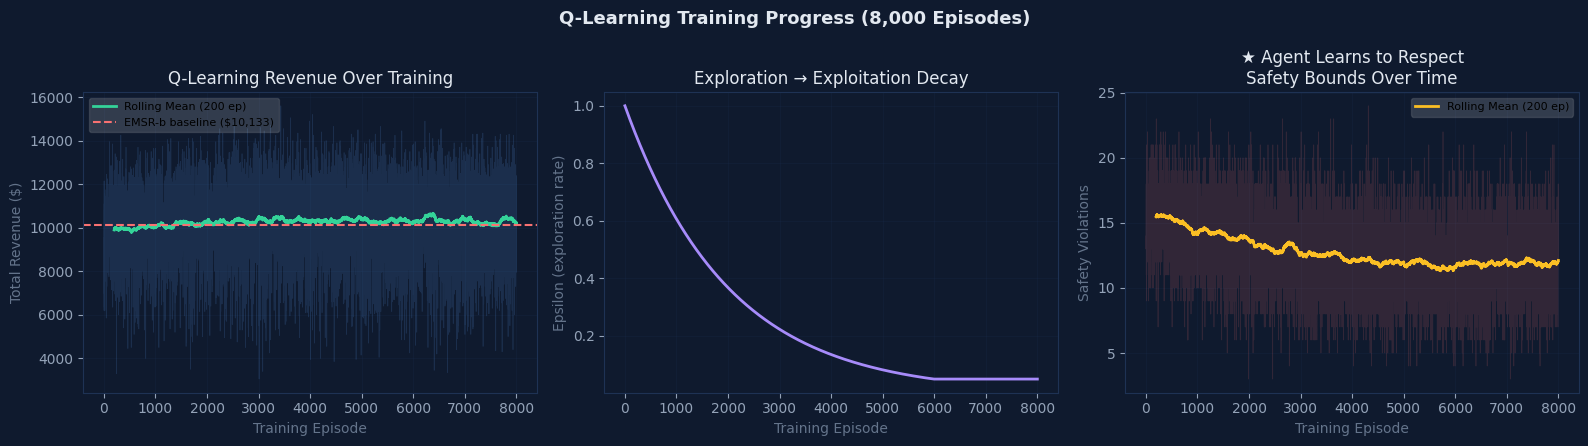

✅ Saved → reports/qlearning_training.png


In [11]:
# ── CELL 11: Visualize Q-Learning Training Progress ──────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.5))
fig2.patch.set_facecolor('#0f1a2e')
for ax in axes2:
    ax.set_facecolor('#0f1a2e')
    for spine in ax.spines.values(): spine.set_edgecolor('#1e3254')
    ax.tick_params(colors='#94a3b8')
    ax.xaxis.label.set_color('#64748b'); ax.yaxis.label.set_color('#64748b')
    ax.title.set_color('#e2e8f0')
 
# Revenue over training (rolling mean)
rolling_rev = pd.Series(episode_revenues).rolling(200).mean()
axes2[0].plot(episode_revenues, color='#60a5fa', alpha=0.15, linewidth=0.5)
axes2[0].plot(rolling_rev, color='#34d399', linewidth=2, label='Rolling Mean (200 ep)')
axes2[0].axhline(np.mean(results['EMSR-b']), color='#f87171', linestyle='--',
                 linewidth=1.5, label=f"EMSR-b baseline (${np.mean(results['EMSR-b']):,.0f})")
axes2[0].set_xlabel('Training Episode'); axes2[0].set_ylabel('Total Revenue ($)')
axes2[0].set_title('Q-Learning Revenue Over Training')
axes2[0].legend(fontsize=8, framealpha=0.15)
axes2[0].grid(alpha=0.2, color='#1e3254')
 
# Epsilon decay
axes2[1].plot(epsilon_history, color='#a78bfa', linewidth=2)
axes2[1].set_xlabel('Training Episode'); axes2[1].set_ylabel('Epsilon (exploration rate)')
axes2[1].set_title('Exploration → Exploitation Decay')
axes2[1].grid(alpha=0.2, color='#1e3254')
 
# Safety violations over training
rolling_viol = pd.Series(episode_safety_violations).rolling(200).mean()
axes2[2].plot(episode_safety_violations, color='#f87171', alpha=0.15, linewidth=0.5)
axes2[2].plot(rolling_viol, color='#fbbf24', linewidth=2, label='Rolling Mean (200 ep)')
axes2[2].set_xlabel('Training Episode'); axes2[2].set_ylabel('Safety Violations')
axes2[2].set_title('★ Agent Learns to Respect\nSafety Bounds Over Time')
axes2[2].legend(fontsize=8, framealpha=0.15)
axes2[2].grid(alpha=0.2, color='#1e3254')
 
plt.suptitle('Q-Learning Training Progress (8,000 Episodes)',
             fontsize=13, fontweight='bold', color='#e2e8f0')
plt.tight_layout()
plt.savefig('../reports/qlearning_training.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/qlearning_training.png")
 

In [12]:
# ── CELL 12: Evaluate Trained Q-Learning Agent ───────────
# Now test the trained agent (epsilon → near 0, mostly exploiting
# its learned Q-table) over 300 fresh episodes for fair comparison
 
print("Evaluating trained Q-Learning agent over 300 episodes...")

env_eval = ContextualAirlinePricingEnv()
q_eval_revenues, q_eval_safety = [], []
 
for ep in tqdm(range(300), desc="Q-Learning Eval"):
    obs, _ = env_eval.reset(seed=ep + 9000)  # different seeds from training
    done = False
    while not done:
        action, _ = agent.choose_action(obs, training=False)  # pure exploitation
        obs, reward, done, _, _ = env_eval.step(action)
    q_eval_revenues.append(env_eval.total_revenue)
    q_eval_safety.append(env_eval.safety_violations)
 
results['Q-Learning'] = q_eval_revenues
safety_results['Q-Learning'] = q_eval_safety
 
print(f"\n✅ Evaluation complete")
print(f"   Mean Revenue        : ${np.mean(q_eval_revenues):,.0f}")
print(f"   Mean Safety Blocks  : {np.mean(q_eval_safety):.2f} per episode")
 

Evaluating trained Q-Learning agent over 300 episodes...


Q-Learning Eval: 100%|██████████| 300/300 [00:03<00:00, 79.82it/s]


✅ Evaluation complete
   Mean Revenue        : $10,487
   Mean Safety Blocks  : 11.39 per episode


In [ ]:
# ── CELL 13: Final Comparison — All Strategies ───────────
fig3, ax3 = plt.subplots(figsize=(11, 5.5))
fig3.patch.set_facecolor('#0f1a2e')
ax3.set_facecolor('#0f1a2e')
for spine in ax3.spines.values(): spine.set_edgecolor('#1e3254')
ax3.tick_params(colors='#94a3b8')
ax3.xaxis.label.set_color('#64748b'); ax3.yaxis.label.set_color('#64748b')
ax3.title.set_color('#e2e8f0')
 
all_names  = list(results.keys())
all_means  = [np.mean(results[n]) for n in all_names]
all_stds   = [np.std(results[n])  for n in all_names]
all_colors = ['#60a5fa', '#fbbf24', '#34d399', '#a78bfa']
 
bars = ax3.bar(all_names, all_means, yerr=all_stds, capsize=6,
              color=all_colors, alpha=0.85, edgecolor='#0f1a2e', width=0.6)
for bar, val in zip(bars, all_means):
    ax3.text(bar.get_x()+bar.get_width()/2, val+150,
             f'${val:,.0f}', ha='center', fontweight='bold',
             fontsize=11, color='#e2e8f0')
 
best_name = all_names[np.argmax(all_means)]
ax3.text(0.5, 1.06, f'★ Best strategy: {best_name}',
         transform=ax3.transAxes, ha='center', fontsize=11,
         color='#34d399', fontweight='bold')
 
ax3.set_ylabel('Mean Total Revenue ($)')
ax3.set_title('Final Comparison — All Pricing Strategies (300 episodes each)')
ax3.set_xticklabels(all_names, rotation=10, ha='right', fontsize=9)
ax3.grid(alpha=0.2, color='#1e3254', axis='y')
 
plt.tight_layout()
plt.savefig('../reports/all_strategies_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1a2e')
plt.show()
print("✅ Saved → reports/all_strategies_comparison.png")
 